<a href="https://colab.research.google.com/github/jay-123-oss/deep-learning-implementation/blob/main/GRU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.optimizers import Adam


In [30]:
data = pd.read_csv('data.csv')
print(data.head())

         Date  Temperature
0  2010-01-01    27.483571
1  2010-01-02    24.308678
2  2010-01-03    28.238443
3  2010-01-04    32.615149
4  2010-01-05    23.829233


In [ ]:
df = pd.read_csv('data.csv', parse_dates=['Date'], index_col='Date')
print(df.head())

            Temperature
Date                   
2010-01-01    27.483571
2010-01-02    24.308678
2010-01-03    28.238443
2010-01-04    32.615149
2010-01-05    23.829233


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8000 entries, 2010-01-01 to 2031-11-26
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  8000 non-null   float64
dtypes: float64(1)
memory usage: 125.0 KB


In [ ]:
print(df.isnull().sum())

Temperature    0
dtype: int64


In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df.values)

In [ ]:
def create_dataset(data, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)


time_step = 100
X, y = create_dataset(scaled_data, time_step)
X = X.reshape(X.shape[0], X.shape[1], 1)

In [ ]:
model = Sequential()
model.add(GRU(units=50, return_sequences=True, input_shape=(X.shape[1], 1)))
model.add(GRU(units=50))
model.add(Dense(units=1))
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 100, 50)        │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,301 (91.02 KB)

 Trainable params: 23,301 (91.02 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(X, y, epochs=10, batch_size=32)

Epoch 1/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 33s 110ms/step - loss: 0.0222
Epoch 2/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 40s 107ms/step - loss: 0.0179
Epoch 3/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 27s 110ms/step - loss: 0.0179
Epoch 4/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 26s 104ms/step - loss: 0.0180
Epoch 5/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 25s 103ms/step - loss: 0.0178
Epoch 6/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 25s 102ms/step - loss: 0.0179
Epoch 7/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 25s 102ms/step - loss: 0.0178
Epoch 8/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 25s 103ms/step - loss: 0.0178
Epoch 9/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 25s 102ms/step - loss: 0.0177
Epoch 10/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 25s 102ms/step - loss: 0.0177


247/247 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step
Root Mean Squared Error (RMSE) on the training data: 5.0415


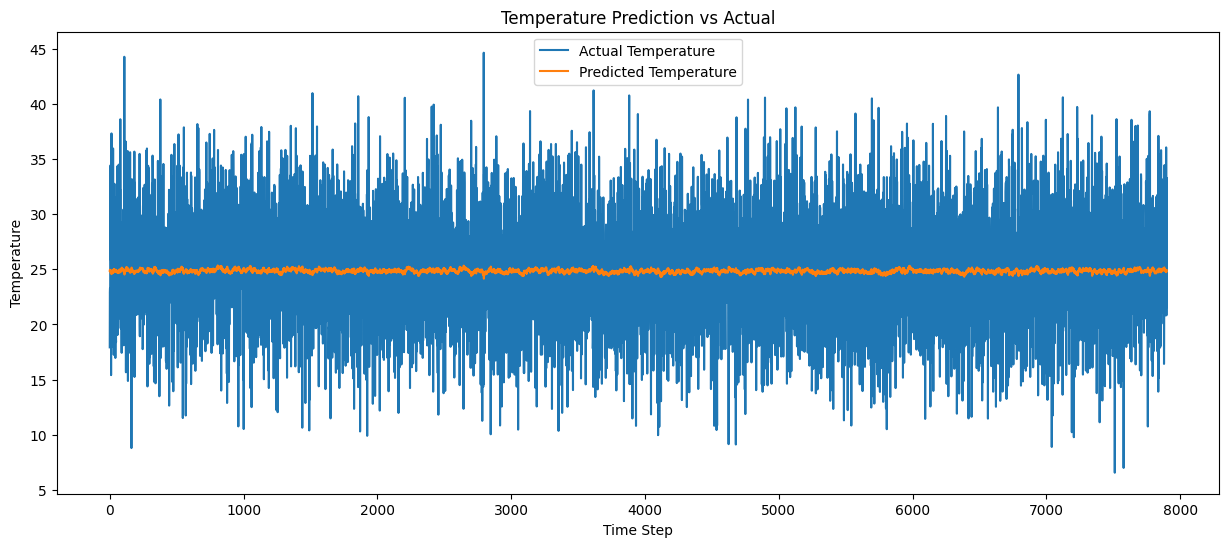

Note: The RMSE and visualization are based on the data the model was trained on. For a more robust evaluation of generalization performance, a proper train-test split should be applied before model training and evaluation should be done on the unseen test set.


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import math

# Make predictions on the entire dataset X
y_pred_scaled = model.predict(X)

# Inverse transform the predictions and actual values to their original scale
y_pred = scaler.inverse_transform(y_pred_scaled)
y_actual = scaler.inverse_transform(y.reshape(-1, 1))

# Calculate RMSE (Root Mean Squared Error)
rmse = math.sqrt(mean_squared_error(y_actual, y_pred))
print(f"Root Mean Squared Error (RMSE) on the training data: {rmse:.4f}")

# Plotting actual vs. predicted values
plt.figure(figsize=(15, 6))
plt.plot(y_actual, label='Actual Temperature')
plt.plot(y_pred, label='Predicted Temperature')
plt.title('Temperature Prediction vs Actual')
plt.xlabel('Time Step')
plt.ylabel('Temperature')
plt.legend()
plt.show()

print("Note: The RMSE and visualization are based on the data the model was trained on. For a more robust evaluation of generalization performance, a proper train-test split should be applied before model training and evaluation should be done on the unseen test set.")

In [ ]:
input_sequence = scaled_data[-time_step:].reshape(1, time_step, 1)
predicted_values = model.predict(input_sequence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


In [ ]:
predicted_values = scaler.inverse_transform(predicted_values)
print(
    f"The predicted temperature for the next day is: {predicted_values[0][0]:.2f}°C")

The predicted temperature for the next day is: 24.70°C
